# AIRA Training Notebook
**Academic Integrity Risk Analyzer — DQN + UCB Training**

This notebook trains all three agents and produces learning curves.
It is designed to run on Google Colab (T4 GPU) or locally.

**Estimated runtime:** ~5 min on Colab T4, ~20 min on CPU.

In [5]:
## Cell 1: Setup & Imports
# Uncomment on Google Colab:
# !pip install torch sentence-transformers gymnasium numpy matplotlib tqdm -q
# !git clone https://github.com/YOUR_USERNAME/TakeHomeFinalProject.git
# %cd TakeHomeFinalProject

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm  # works in both Jupyter and CLI/nbconvert
import torch

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

Device: mps


In [6]:
## Cell 2: Load Data and Build Environment
from src.preprocessing.segmenter import segment_policy
from src.env.clause_auditor_env import ClauseAuditorEnv

POLICY_PATH = '../data/raw/synthetic_policy.txt'
ANNOTATIONS_PATH = '../data/annotated/synthetic_contradictions.json'
DOC_PREFIX = 'SYN'

# Segment
with open(POLICY_PATH) as f:
    text = f.read()
clauses = segment_policy(text, DOC_PREFIX)
print(f'Clauses: {len(clauses)}')

# Embeddings — use random for fast testing, sentence-transformers for real run
USE_REAL_EMBEDDINGS = False  # Set True when sentence-transformers is installed

if USE_REAL_EMBEDDINGS:
    from src.preprocessing.embedder import ClauseEmbedder
    embedder = ClauseEmbedder(cache_dir='../data/processed')
    embeddings = embedder.embed_clauses(clauses, doc_name=DOC_PREFIX)
else:
    rng = np.random.default_rng(SEED)
    embeddings = rng.random((len(clauses), 384)).astype(np.float32)
    embeddings /= np.linalg.norm(embeddings, axis=1, keepdims=True)

# Ground truth
with open(ANNOTATIONS_PATH) as f:
    ann = json.load(f)
gt_pairs = {frozenset({c['clause_a'], c['clause_b']}) for c in ann['contradictions']}
print(f'Ground truth pairs: {len(gt_pairs)}')

env = ClauseAuditorEnv(clauses, embeddings, gt_pairs, budget_fraction=0.15)
print(f'Total pairs: {env._n_pairs}, Budget: {env._budget}')

Clauses: 17
Ground truth pairs: 8
Total pairs: 136, Budget: 0


In [7]:
## Cell 3: Initialize Agents and Hyperparameters
from src.agents.dqn_agent import DQNAgent
from src.agents.ucb_explorer import UCBExplorer
from src.agents.replay_buffer import ReplayBuffer

HP = {
    'episodes': 500,
    'batch_size': 64,
    'epsilon_start': 1.0,
    'epsilon_end': 0.05,
    'gamma': 0.99,
    'lr': 1e-4,
    'buffer_capacity': 50_000,
    'budget_fraction': 0.15,
    'curriculum_start': 0.30,
    'curriculum_episodes': 200,
    'ucb_c': 0.3,           # tuned: prevents UCB bonus from overpowering Q-values
    'ucb_warm_start': 10,   # short warm-start; visit counts now accumulate across episodes
    'checkpoint_every': 100,
}

epsilon_decay_steps = HP['episodes'] * env._budget if env._budget > 0 else HP['episodes'] * 20

# DQN agent
dqn_agent = DQNAgent(
    state_dim=772, n_actions=2, lr=HP['lr'], gamma=HP['gamma'],
    device=DEVICE, epsilon_start=HP['epsilon_start'],
    epsilon_end=HP['epsilon_end'], epsilon_decay_steps=epsilon_decay_steps
)

# UCB agent wraps a fresh DQN
dqn_ucb_base = DQNAgent(
    state_dim=772, n_actions=2, lr=HP['lr'], gamma=HP['gamma'],
    device=DEVICE, epsilon_start=HP['epsilon_start'],
    epsilon_end=HP['epsilon_end'], epsilon_decay_steps=epsilon_decay_steps
)
ucb_agent = UCBExplorer(dqn_ucb_base, n_pairs=env._n_pairs,
                         c=HP['ucb_c'], warm_start_episodes=HP['ucb_warm_start'])

buffer_dqn = ReplayBuffer(capacity=HP['buffer_capacity'], device=DEVICE)
buffer_ucb = ReplayBuffer(capacity=HP['buffer_capacity'], device=DEVICE)

print('Agents initialized.')
print(f'UCB c={HP["ucb_c"]}, warm_start={HP["ucb_warm_start"]}')

Agents initialized.
UCB c=0.3, warm_start=10


In [8]:
## Cell 4: Training Loop
from src.env.reward import COMPARE, SKIP

def curriculum_budget(ep):
    start = HP['curriculum_start']
    end = HP['budget_fraction']
    prog = min(ep / HP['curriculum_episodes'], 1.0)
    return start - prog * (start - end)

def train_agent(agent, buffer, episodes, env, use_ucb=False, label='Agent'):
    rewards, losses, recalls, precisions = [], [], [], []
    for ep in tqdm(range(episodes), desc=label):
        env.curriculum_budget = curriculum_budget(ep)
        if use_ucb:
            agent.reset()
        obs, info = env.reset(seed=ep)
        ep_reward, ep_losses = 0.0, []

        while True:
            if use_ucb:
                i, j = env._pair_queue[env._queue_idx]
                n = len(env.clauses)
                flat_idx = UCBExplorer.pair_to_idx(min(i,j), max(i,j), n)
                action = agent.select_action(obs, flat_idx)
            else:
                action = agent.select_action(obs)

            next_obs, reward, terminated, truncated, step_info = env.step(action)
            done = terminated or truncated
            buffer.push(obs, action, reward, next_obs, float(done))
            ep_reward += reward

            if buffer.ready():
                loss = agent.learn(buffer, batch_size=HP['batch_size'])
                ep_losses.append(loss)
            obs = next_obs
            if done:
                break

        # Metrics
        decisions = env.get_decisions()
        n_cmp = sum(1 for a in decisions.values() if a == COMPARE)
        tp = sum(1 for k, a in decisions.items() if a == COMPARE and k in env.ground_truth_pairs)
        fn = sum(1 for k in env.ground_truth_pairs if decisions.get(k) == COMPARE)

        rewards.append(ep_reward)
        losses.append(float(np.mean(ep_losses)) if ep_losses else 0.0)
        precisions.append(tp / max(n_cmp, 1))
        recalls.append(fn / max(len(env.ground_truth_pairs), 1))

    return {'rewards': rewards, 'losses': losses,
            'precisions': precisions, 'recalls': recalls}

print('Training DQN...')
dqn_results = train_agent(dqn_agent, buffer_dqn, HP['episodes'], env, use_ucb=False, label='DQN')

print('Training DQN+UCB...')
ucb_results = train_agent(ucb_agent, buffer_ucb, HP['episodes'], env, use_ucb=True, label='DQN+UCB')

print('Training complete!')

Training DQN...


DQN:   0%|          | 0/500 [00:00<?, ?it/s]

Training DQN+UCB...


DQN+UCB:   0%|          | 0/500 [00:00<?, ?it/s]

Training complete!


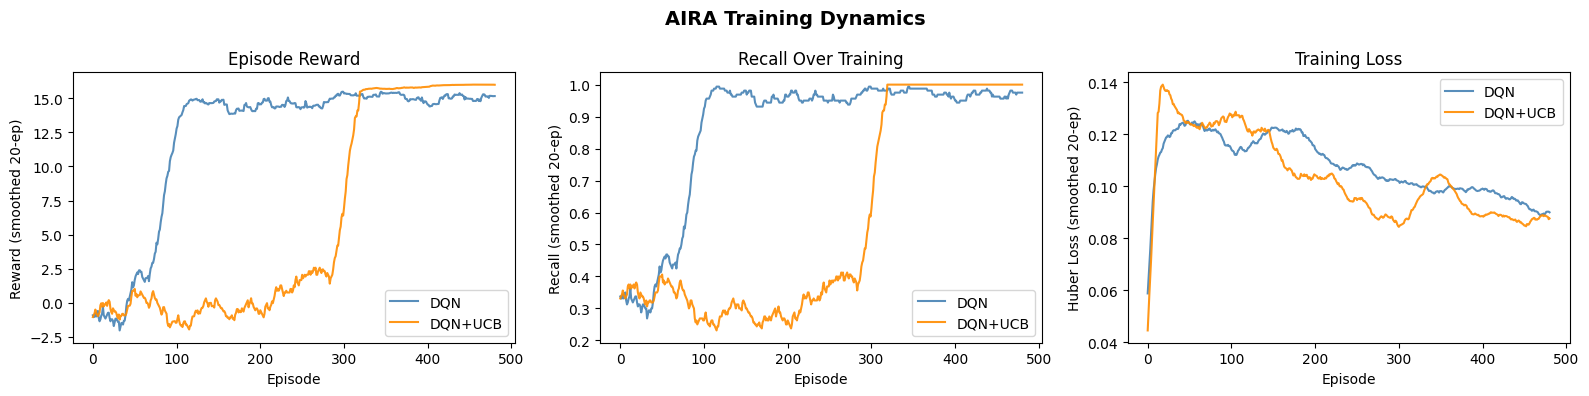

Saved learning_curve.png


In [9]:
## Cell 5: Plot Learning Curves
os.makedirs('../results/figures', exist_ok=True)

def smooth(data, window=20):
    if len(data) < window:
        return data
    return np.convolve(data, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('AIRA Training Dynamics', fontsize=14, fontweight='bold')

# Reward curves
axes[0].plot(smooth(dqn_results['rewards']), label='DQN', color='steelblue', alpha=0.9)
axes[0].plot(smooth(ucb_results['rewards']), label='DQN+UCB', color='darkorange', alpha=0.9)
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Reward (smoothed 20-ep)')
axes[0].set_title('Episode Reward'); axes[0].legend()

# Recall curves
axes[1].plot(smooth(dqn_results['recalls']), label='DQN', color='steelblue', alpha=0.9)
axes[1].plot(smooth(ucb_results['recalls']), label='DQN+UCB', color='darkorange', alpha=0.9)
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Recall (smoothed 20-ep)')
axes[1].set_title('Recall Over Training'); axes[1].legend()

# Loss curves
axes[2].plot(smooth(dqn_results['losses']), label='DQN', color='steelblue', alpha=0.9)
axes[2].plot(smooth(ucb_results['losses']), label='DQN+UCB', color='darkorange', alpha=0.9)
axes[2].set_xlabel('Episode'); axes[2].set_ylabel('Huber Loss (smoothed 20-ep)')
axes[2].set_title('Training Loss'); axes[2].legend()

plt.tight_layout()
plt.savefig('../results/figures/learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved learning_curve.png')

In [10]:
## Cell 6: Evaluate Final Agent on Held-Out Data
from src.evaluation.baselines import RandomAgent, run_agent_episode

N_EVAL = 50
random_agent = RandomAgent(compare_prob=HP['budget_fraction'], seed=99)

# Reset curriculum_budget to normal
env.curriculum_budget = None

def eval_agent(agent, n_episodes, use_ucb=False):
    precisions, recalls, efficiencies, rewards = [], [], [], []
    for ep in range(n_episodes):
        if use_ucb:
            agent.reset()
        obs, info = env.reset(seed=1000 + ep)
        ep_reward = 0.0
        while True:
            if use_ucb:
                i, j = env._pair_queue[env._queue_idx]
                n = len(env.clauses)
                flat_idx = UCBExplorer.pair_to_idx(min(i,j), max(i,j), n)
                action = agent.select_action(obs, flat_idx)
            elif hasattr(agent, 'select_action'):
                action = agent.select_action(obs)
            next_obs, reward, terminated, truncated, step_info = env.step(action)
            ep_reward += reward
            obs = next_obs
            if terminated or truncated:
                break
        decisions = env.get_decisions()
        n_cmp = sum(1 for a in decisions.values() if a == COMPARE)
        tp = sum(1 for k, a in decisions.items() if a == COMPARE and k in env.ground_truth_pairs)
        precisions.append(tp / max(n_cmp, 1))
        recalls.append(sum(1 for k in env.ground_truth_pairs if decisions.get(k) == COMPARE)
                        / max(len(env.ground_truth_pairs), 1))
        efficiencies.append(n_cmp / env._n_pairs)
        rewards.append(ep_reward)
    return {
        'precision': np.mean(precisions), 'recall': np.mean(recalls),
        'f1': 2*np.mean(precisions)*np.mean(recalls)/max(np.mean(precisions)+np.mean(recalls), 1e-9),
        'efficiency': np.mean(efficiencies), 'reward': np.mean(rewards)
    }

rand_eval = eval_agent(random_agent, N_EVAL)
dqn_eval = eval_agent(dqn_agent, N_EVAL, use_ucb=False)
ucb_eval = eval_agent(ucb_agent, N_EVAL, use_ucb=True)

print('\nFinal Evaluation Results (avg over 50 episodes):')
print(f'{"Metric":<22} {"Random":>10} {"DQN":>10} {"DQN+UCB":>10}')
print('-' * 55)
for k in ['precision', 'recall', 'f1', 'efficiency']:
    print(f'{k:<22} {rand_eval[k]:>10.3f} {dqn_eval[k]:>10.3f} {ucb_eval[k]:>10.3f}')


Final Evaluation Results (avg over 50 episodes):
Metric                     Random        DQN    DQN+UCB
-------------------------------------------------------
precision                   0.044      0.724      0.968
recall                      0.105      0.963      1.000
f1                          0.062      0.826      0.984
efficiency                  0.136      0.081      0.061
